# DECA Model Training Notebook

Trains the full prediction stack from `docs/DECA_Model_Development_Blueprint.md` on
`data/processed/deca_unified_dataset.parquet`, with **inline plots for every stage**.

| Stage | Model |
| --- | --- |
| 0 | Data load + label audit |
| 1 | Isolation Forest + Platt calibration |
| 2 | Phase-1 unified_label classifier (gate + weights + thresholds) |
| 3 | Prophet macro forecasts |
| 4 | LSTM time-to-breach |
| 5 | Feature attribution + CE–PE–CE topology |
| 6 | Write `models/` artifacts + `manifest.json` |

**Run from repo root** (or set `REPO_ROOT` below). Kernel: project `.venv`.


In [1]:
from __future__ import annotations

import json
import shutil
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from prophet import Prophet
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    mean_absolute_error,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")
%matplotlib inline

# Repo root = parent of notebook/
REPO_ROOT = Path.cwd()
if (REPO_ROOT / "notebook").is_dir() and (REPO_ROOT / "data").is_dir():
    pass
elif (REPO_ROOT.parent / "data").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "scripts"))

from _paths import MODELS_DIR, PROCESSED_DIR  # noqa: E402
from rebuild_unified import UNIFIED_LABELS, to_unified_label  # noqa: E402

SEQ_LEN = 16
RANDOM_STATE = 42
META_COLS = {
    "run_id", "source", "fault_type", "unified_label",
    "is_anomaly", "time_to_breach_minutes", "timestamp",
}
MODEL_DIRS = {
    "isolation_forest": "isolation_forest",
    "fault_classifier": "fault_classifier",
    "prophet_ifInOctets": "prophet_ifInOctets",
    "prophet_jitter_ms": "prophet_jitter_ms",
    "prophet_bgp_update_rate": "prophet_bgp_update_rate",
    "lstm": "lstm",
    "topology": "topology",
}

def model_dir(name: str) -> Path:
    d = MODELS_DIR / MODEL_DIRS.get(name, name)
    d.mkdir(parents=True, exist_ok=True)
    return d

def rel_model_path(name: str, filename: str) -> str:
    return f"models/{MODEL_DIRS.get(name, name)}/{filename}"

def feature_columns(df: pd.DataFrame) -> list[str]:
    return [
        c for c in df.columns
        if c not in META_COLS and (
            c.endswith("_slope") or c.endswith("_rolling_std")
            or c.endswith("_rolling_mean") or c.endswith("_accel")
        )
    ]

def wipe_models():
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    n = 0
    for p in list(MODELS_DIR.iterdir()):
        if p.is_file():
            p.unlink(); n += 1
        elif p.is_dir():
            shutil.rmtree(p); n += 1
    print(f"Cleared models/ ({n} entries)")

print("REPO_ROOT =", REPO_ROOT)
print("PROCESSED =", PROCESSED_DIR)
print("MODELS   =", MODELS_DIR)


/home/brain/deca-isro/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
I0000 00:00:1784097421.905021   86457 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784097421.980416   86457 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784097423.674907   86457 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


REPO_ROOT = /home/brain/deca-isro
PROCESSED = /home/brain/deca-isro/data/processed
MODELS   = /home/brain/deca-isro/models


## Stage 0 — Load unified dataset & audit labels


Cleared models/ (10 entries)
rows=17,050  features=20  sources={'network': 8772, 'public': 8278}


,count
unified_label,
healthy,15804
congestion_breach,430
tunnel_degradation,306
bgp_route_flap,300
vrf_leakage,210


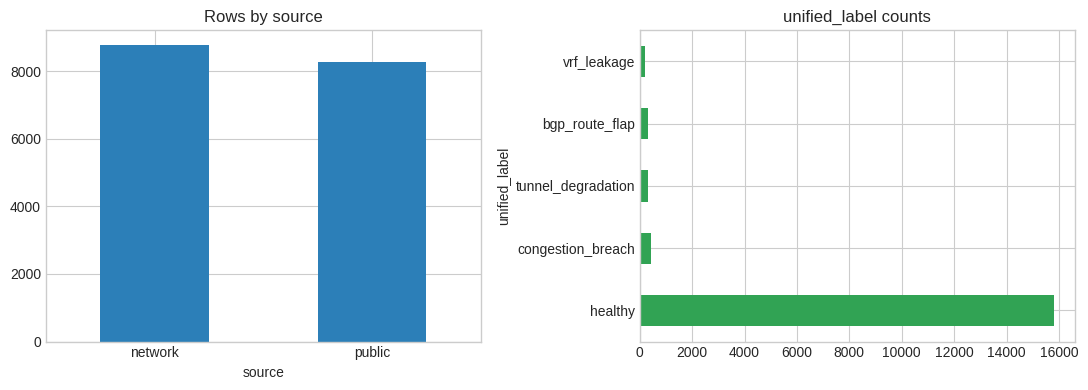

In [2]:
wipe_models()
path = PROCESSED_DIR / "deca_unified_dataset.parquet"
df = pd.read_parquet(path)
if "unified_label" not in df.columns:
    df["unified_label"] = df["fault_type"].map(to_unified_label)
if "is_anomaly" not in df.columns:
    df["is_anomaly"] = (df["unified_label"] != "healthy").astype(int)
if not isinstance(df.index, pd.DatetimeIndex):
    if "timestamp" in df.columns:
        df = df.set_index(pd.to_datetime(df["timestamp"], utc=True))
    else:
        df.index = pd.to_datetime(df.index, utc=True)
df = df.sort_index()
feats = feature_columns(df)
print(f"rows={len(df):,}  features={len(feats)}  sources={df['source'].value_counts().to_dict()}")
display(df["unified_label"].value_counts().to_frame("count"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["source"].value_counts().plot(kind="bar", ax=axes[0], color="#2c7fb8", title="Rows by source")
df["unified_label"].value_counts().plot(kind="barh", ax=axes[1], color="#31a354", title="unified_label counts")
axes[0].tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()


## Stage 0b — Fault behaviour gallery (visual signatures)

Plot how each lab fault type looks in telemetry. Uses the completed campaign export
(`network_campaign_export.csv` + `fault_injection_log.csv`).

| Fault | What to look for |
| --- | --- |
| `congestion_breach` | Throughput collapse / step-down; latency + jitter rise |
| `tunnel_degradation` | Jitter / latency spikes on VPN path while L3 stays up |
| `bgp_route_flap` | Burstier loss / reachability instability during flap windows |
| `vrf_leakage` | Odd traffic / loss patterns while wrong route-target is injected |

Shaded band = `[fault_start → breach_time]` for one representative run per type.


Using campaign: 20260713_155333
hosts: ['station1', 'ubuntu']
faults by type:
 fault_type
congestion_breach     6
bgp_route_flap        5
tunnel_degradation    5
vrf_leakage           5
plot host: station1


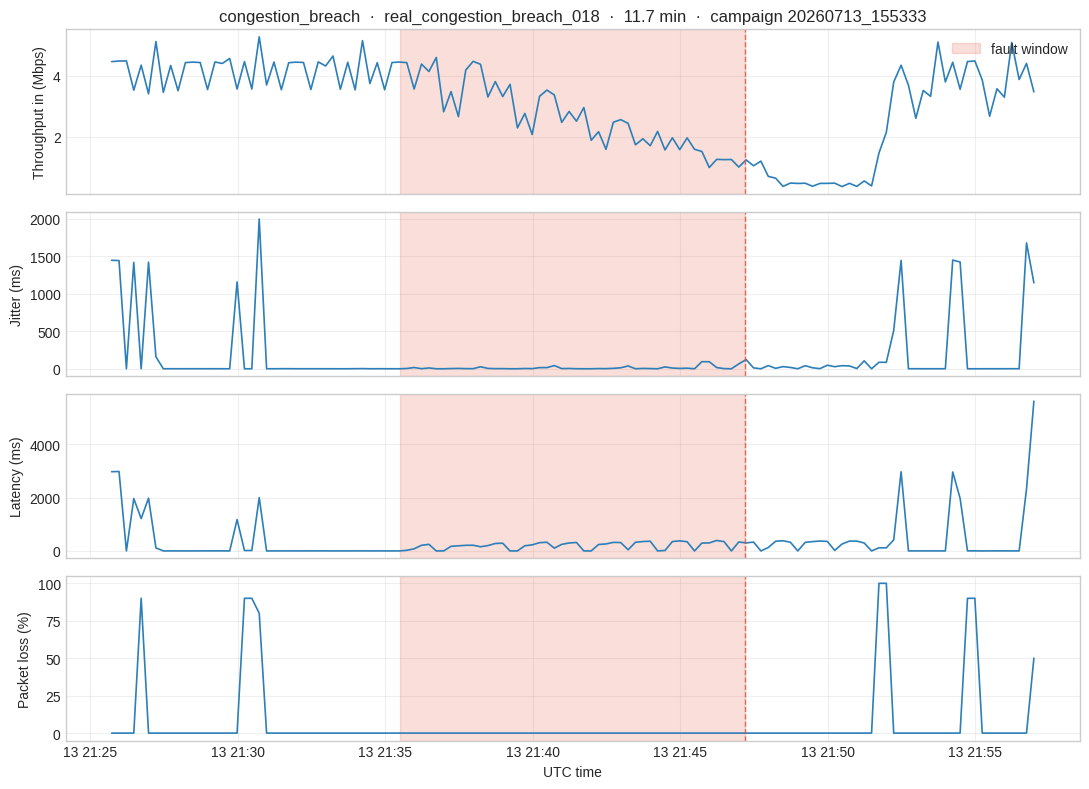

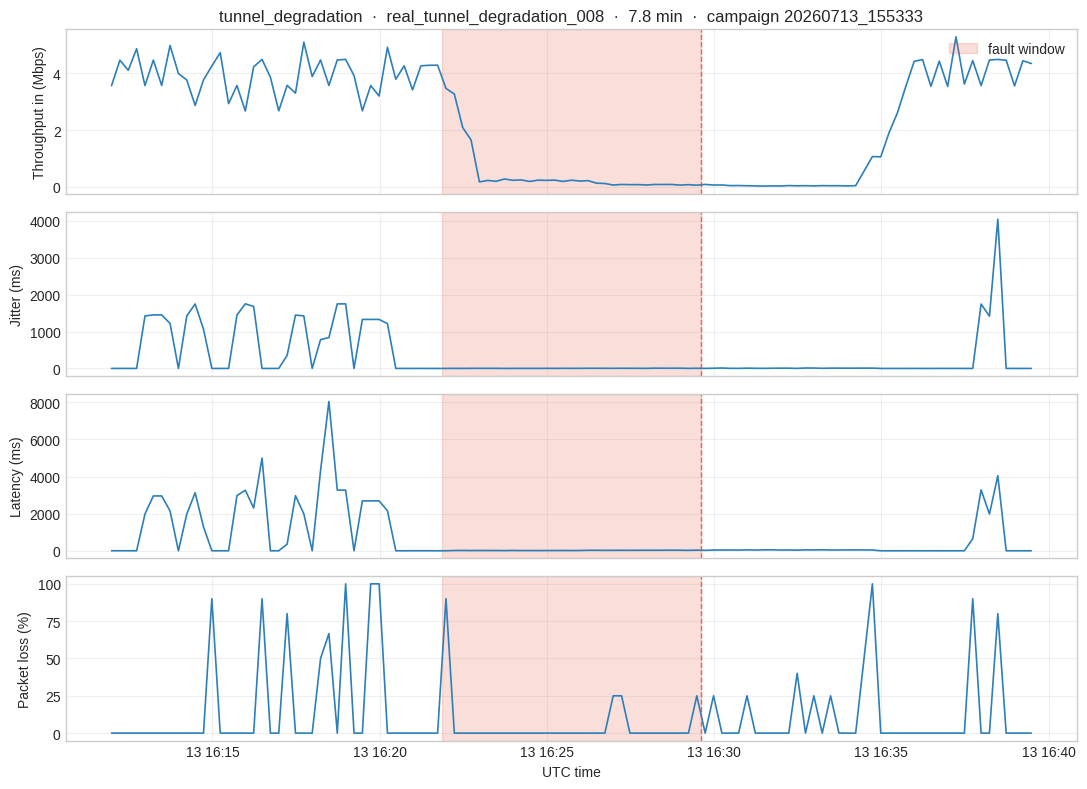

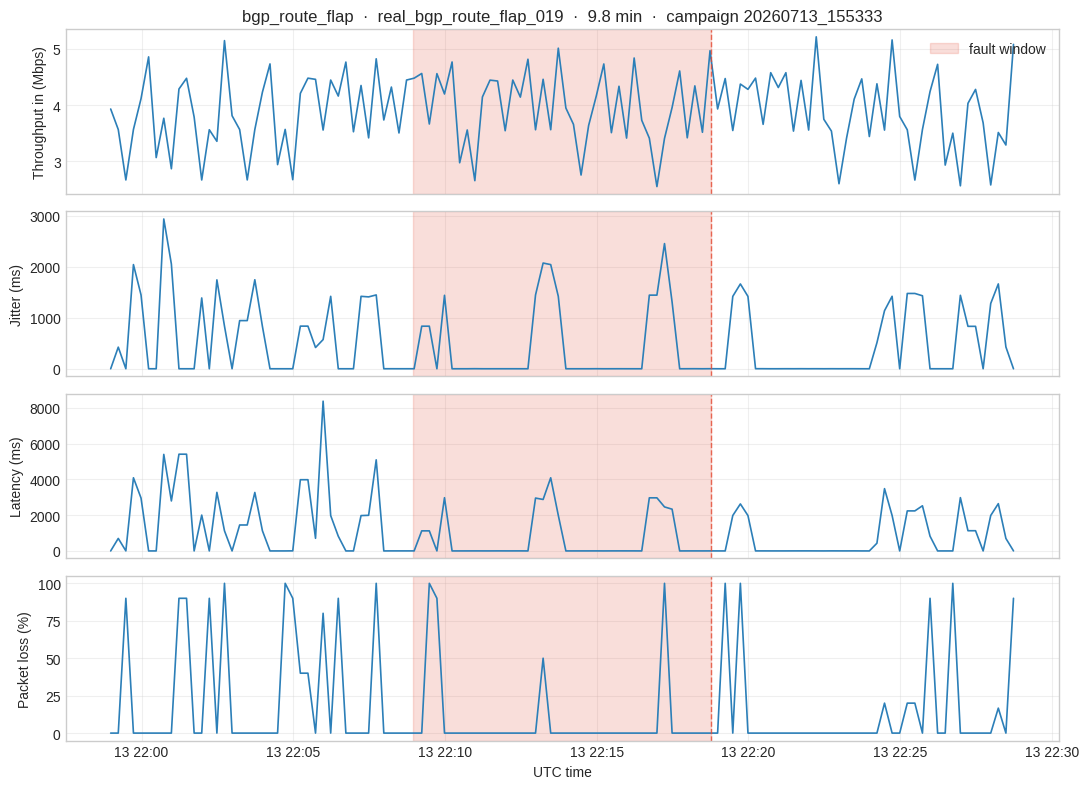

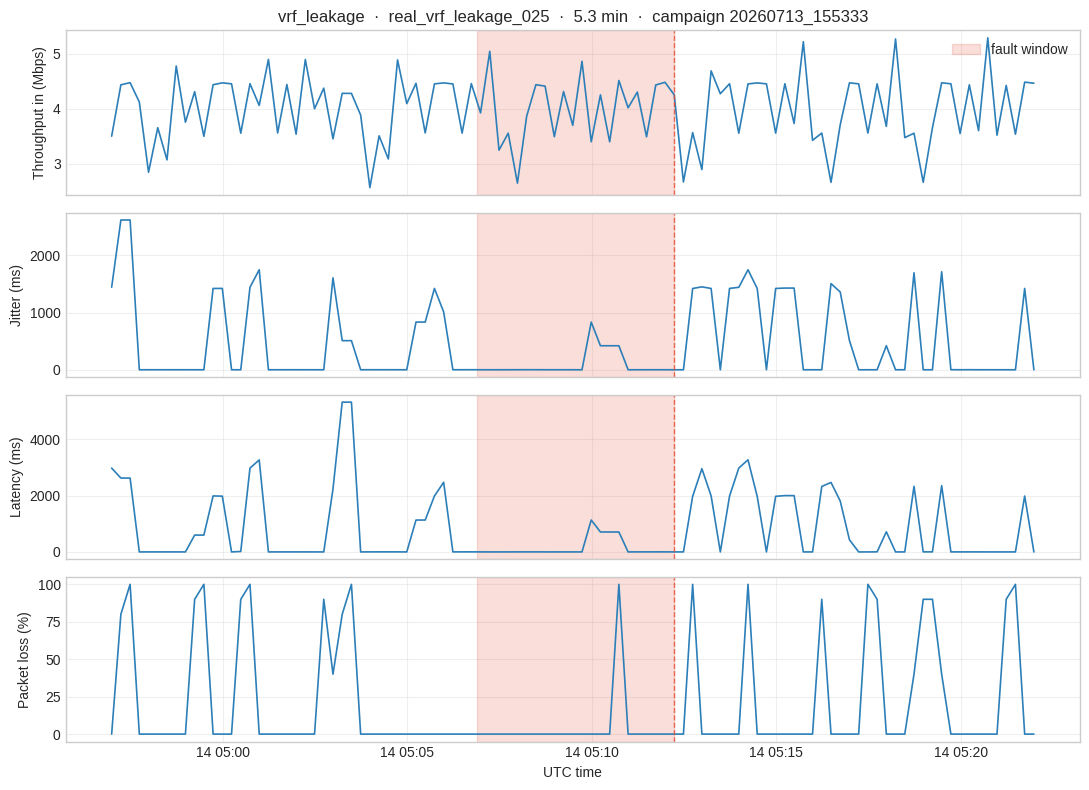

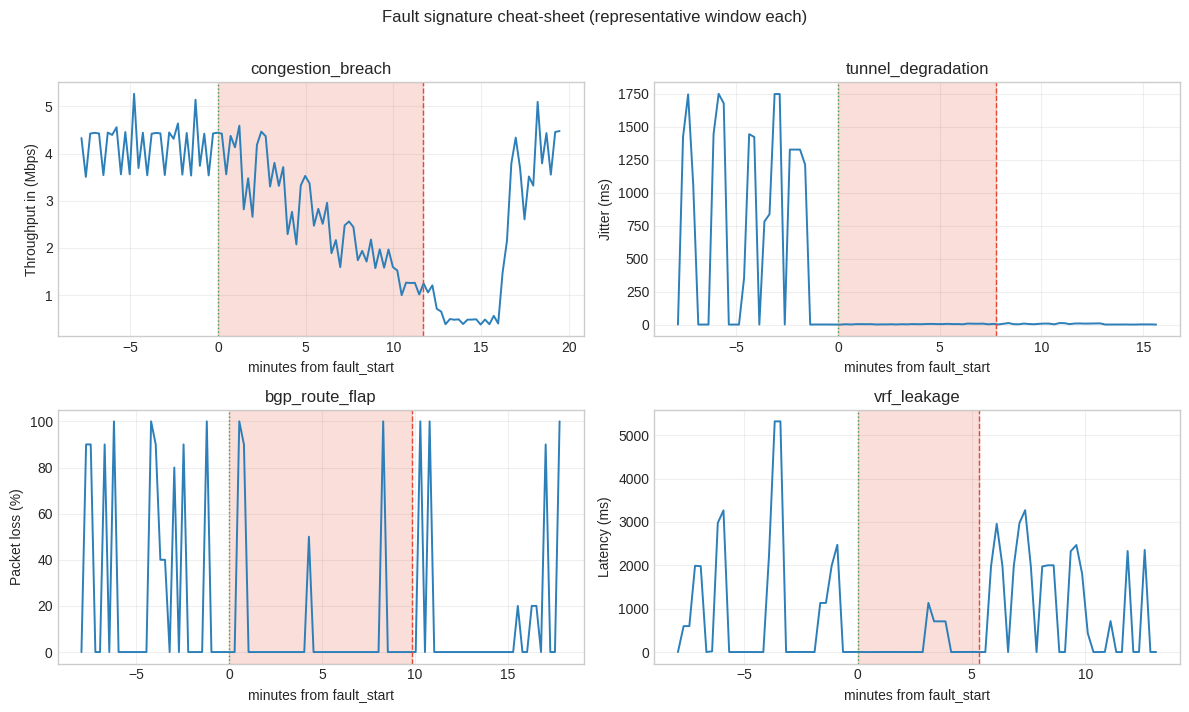

Re-run this cell to refresh live plots. Static copies (if previously exported) live under: /home/brain/deca-isro/notebook/figures/fault_behaviour


,fault_type,run_id,fault_start,breach_time,duration_min
0,bgp_route_flap,real_bgp_route_flap_002,2026-07-13 11:22:24.818818+00:00,2026-07-13 11:32:15.136668+00:00,9.838631
1,bgp_route_flap,real_bgp_route_flap_004,2026-07-13 13:01:17.626503+00:00,2026-07-13 13:08:31.722485+00:00,7.234933
2,bgp_route_flap,real_bgp_route_flap_010,2026-07-13 17:26:44.684768+00:00,2026-07-13 17:36:47.398045+00:00,10.045221
3,bgp_route_flap,real_bgp_route_flap_013,2026-07-13 19:03:04.435143+00:00,2026-07-13 19:10:27.101767+00:00,7.377777
4,bgp_route_flap,real_bgp_route_flap_019,2026-07-13 22:08:56.200502+00:00,2026-07-13 22:18:45.649906+00:00,9.824157
5,congestion_breach,real_congestion_breach_001,2026-07-13 10:48:17.820456+00:00,2026-07-13 10:57:30.237215+00:00,9.206946
6,congestion_breach,real_congestion_breach_006,2026-07-13 14:04:03.231354+00:00,2026-07-13 14:18:07.613181+00:00,14.073030
7,congestion_breach,real_congestion_breach_011,2026-07-13 18:00:00.685984+00:00,2026-07-13 18:11:09.549106+00:00,11.147719
8,congestion_breach,real_congestion_breach_016,2026-07-13 20:34:04.921413+00:00,2026-07-13 20:41:55.876330+00:00,7.849249
9,congestion_breach,real_congestion_breach_018,2026-07-13 21:35:30.822436+00:00,2026-07-13 21:47:11.002077+00:00,11.669661


In [3]:
from pathlib import Path as _Path

# Prefer completed labeled export; fall back to newest run that has it
_runs = REPO_ROOT / "data" / "rpi-net" / "runs"
_candidates = sorted(
    [p for p in _runs.glob("*/network_campaign_export.csv") if p.is_file()],
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
if not _candidates:
    raise FileNotFoundError(
        "No network_campaign_export.csv under data/rpi-net/runs/ — "
        "finish a campaign (or use 20260713_155333) before plotting fault behaviour."
    )

CAMPAIGN_EXPORT = _candidates[0]
CAMPAIGN_DIR = CAMPAIGN_EXPORT.parent
FAULT_LOG = CAMPAIGN_DIR / "fault_injection_log.csv"
print("Using campaign:", CAMPAIGN_DIR.name)

telem = pd.read_csv(CAMPAIGN_EXPORT)
telem["timestamp"] = pd.to_datetime(telem["timestamp"], utc=True)
flog = pd.read_csv(FAULT_LOG)
flog["fault_start"] = pd.to_datetime(flog["fault_start"], utc=True)
flog["breach_time"] = pd.to_datetime(flog["breach_time"], utc=True)
flog["duration_min"] = (flog["breach_time"] - flog["fault_start"]).dt.total_seconds() / 60.0

# Prefer PE1-ish host if present (station1); else average later per metric
hosts = sorted(telem["host"].dropna().astype(str).unique())
print("hosts:", hosts)
print("faults by type:\n", flog["fault_type"].value_counts().to_string())

METRICS = [
    ("throughput_in_mbps", "Throughput in (Mbps)"),
    ("jitter_ms", "Jitter (ms)"),
    ("latency_ms", "Latency (ms)"),
    ("packet_loss_pct", "Packet loss (%)"),
]
FAULT_ORDER = ["congestion_breach", "tunnel_degradation", "bgp_route_flap", "vrf_leakage"]


def _pick_host(frame: pd.DataFrame) -> pd.DataFrame:
    for pref in ("station1", "ubuntu"):  # ubuntu = historical station2 mis-hostname
        sub = frame[frame["host"].astype(str) == pref]
        if len(sub) >= 20:
            return sub
    # fallback: mean across hosts
    num = [c for c, _ in METRICS if c in frame.columns]
    g = (
        frame.groupby("timestamp", as_index=False)[num]
        .mean(numeric_only=True)
    )
    g["host"] = "mean"
    return g


def _window_slice(frame: pd.DataFrame, start, end, pad_min: float = 8.0) -> pd.DataFrame:
    lo = start - pd.Timedelta(minutes=pad_min)
    hi = end + pd.Timedelta(minutes=pad_min)
    return frame[(frame["timestamp"] >= lo) & (frame["timestamp"] <= hi)].copy()


def _representative_fault(ftype: str) -> pd.Series | None:
    sub = flog[flog["fault_type"] == ftype].copy()
    if sub.empty:
        return None
    # median-duration window — typical, not outlier
    sub = sub.sort_values("duration_min")
    return sub.iloc[len(sub) // 2]


host_telem = _pick_host(telem)
print("plot host:", host_telem["host"].iloc[0] if "host" in host_telem.columns else "mean")

# ---- 1) One multi-metric strip per fault type ----
for ftype in FAULT_ORDER:
    row = _representative_fault(ftype)
    if row is None:
        print(f"skip {ftype}: no rows in fault log")
        continue
    w = _window_slice(host_telem, row["fault_start"], row["breach_time"], pad_min=10)
    if w.empty:
        print(f"skip {ftype}: no telemetry in window")
        continue

    fig, axes = plt.subplots(len(METRICS), 1, figsize=(11, 8), sharex=True)
    if len(METRICS) == 1:
        axes = [axes]
    t0 = row["fault_start"]
    for ax, (col, label) in zip(axes, METRICS):
        if col not in w.columns:
            ax.set_visible(False)
            continue
        ax.plot(w["timestamp"], w[col], color="#2c7fb8", lw=1.2)
        ax.axvspan(row["fault_start"], row["breach_time"], color="#e34a33", alpha=0.18, label="fault window")
        ax.axvline(row["breach_time"], color="#e34a33", ls="--", lw=1, alpha=0.8)
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)
    axes[0].set_title(
        f"{ftype}  ·  {row['run_id']}  ·  "
        f"{row['duration_min']:.1f} min  ·  campaign {CAMPAIGN_DIR.name}"
    )
    axes[0].legend(loc="upper right")
    axes[-1].set_xlabel("UTC time")
    fig.tight_layout()
    plt.show()

# ---- 2) Side-by-side signature panel (one KPI per fault) ----
# KPI chosen to make each fault's "shape" obvious at a glance
KPI = {
    "congestion_breach": ("throughput_in_mbps", "Throughput in (Mbps)"),
    "tunnel_degradation": ("jitter_ms", "Jitter (ms)"),
    "bgp_route_flap": ("packet_loss_pct", "Packet loss (%)"),
    "vrf_leakage": ("latency_ms", "Latency (ms)"),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=False)
axes = axes.ravel()
for ax, ftype in zip(axes, FAULT_ORDER):
    row = _representative_fault(ftype)
    col, label = KPI[ftype]
    if row is None:
        ax.set_title(f"{ftype}: missing")
        continue
    w = _window_slice(host_telem, row["fault_start"], row["breach_time"], pad_min=8)
    if w.empty or col not in w.columns:
        ax.set_title(f"{ftype}: no data")
        continue
    # normalize time to minutes from fault_start for overlay-friendly x
    mins = (w["timestamp"] - row["fault_start"]).dt.total_seconds() / 60.0
    ax.plot(mins, w[col], color="#2c7fb8", lw=1.4)
    ax.axvspan(0, row["duration_min"], color="#e34a33", alpha=0.18)
    ax.axvline(0, color="#31a354", ls=":", lw=1)
    ax.axvline(row["duration_min"], color="#e34a33", ls="--", lw=1)
    ax.set_title(ftype)
    ax.set_ylabel(label)
    ax.set_xlabel("minutes from fault_start")
    ax.grid(True, alpha=0.3)
fig.suptitle("Fault signature cheat-sheet (representative window each)", y=1.01)
fig.tight_layout()
plt.show()

# Persist copies for the repo / demo pack
_fig_dir = REPO_ROOT / "notebook" / "figures" / "fault_behaviour"
_fig_dir.mkdir(parents=True, exist_ok=True)
print("Re-run this cell to refresh live plots. Static copies (if previously exported) live under:", _fig_dir)

display(flog[["fault_type", "run_id", "fault_start", "breach_time", "duration_min"]]
        .sort_values(["fault_type", "fault_start"])
        .reset_index(drop=True))


## Stage 1 — Isolation Forest + Platt calibration

Fit IF on **healthy** train rows only. Platt (logistic) maps anomaly scores → $P(\text{anomaly})$.
Plots: score distributions, ROC curve.


IF+Platt ROC-AUC=0.7204  test n=4263  anomalies=312


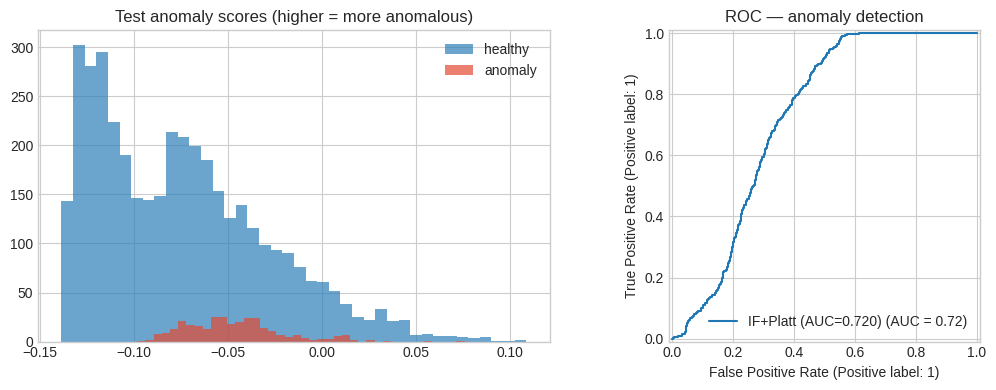

In [4]:
X = df[feats]
y_bin = df["is_anomaly"].astype(int).values
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_bin, test_size=0.25, random_state=RANDOM_STATE, stratify=y_bin
)
healthy = y_tr == 0
if_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("scaler", StandardScaler()),
    ("iforest", IsolationForest(
        n_estimators=300,
        contamination=min(0.08, max(0.02, float(y_tr.mean()) or 0.05)),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
if_pipe.fit(X_tr[healthy])

def anom_score(frame):
    return -if_pipe.decision_function(frame)

tr_scores = anom_score(X_tr)
te_scores = anom_score(X_te)
calibrator = LogisticRegression(max_iter=1000)
calibrator.fit(tr_scores.reshape(-1, 1), y_tr)
te_prob = calibrator.predict_proba(te_scores.reshape(-1, 1))[:, 1]
auc = roc_auc_score(y_te, te_prob)
print(f"IF+Platt ROC-AUC={auc:.4f}  test n={len(y_te)}  anomalies={int(y_te.sum())}")

out_if = model_dir("isolation_forest")
joblib.dump(if_pipe, out_if / "isolation_forest.pkl")
joblib.dump(calibrator, out_if / "confidence_calibrator.pkl")
joblib.dump(
    {"imputer": if_pipe.named_steps["imputer"], "scaler": if_pipe.named_steps["scaler"],
     "feature_columns": feats},
    out_if / "feature_scaler.pkl",
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(te_scores[y_te == 0], bins=40, alpha=0.7, label="healthy", color="#2c7fb8")
axes[0].hist(te_scores[y_te == 1], bins=40, alpha=0.7, label="anomaly", color="#e34a33")
axes[0].set_title("Test anomaly scores (higher = more anomalous)")
axes[0].legend()
RocCurveDisplay.from_predictions(y_te, te_prob, ax=axes[1], name=f"IF+Platt (AUC={auc:.3f})")
axes[1].set_title("ROC — anomaly detection")
fig.tight_layout()
plt.show()

if_stats = {"auc": float(auc), "contamination": float(if_pipe.named_steps["iforest"].contamination)}


## Stage 2 — Phase 1 unified_label classifier

**Tier 1** two-stage gate · **Tier 2** inverse-frequency weights · **Tier 3** val-tuned thresholds · **Tier 4** SMOTE refused.

Plots: confusion matrix, per-class F1 bars, precision-recall for rare classes.


mode=weighted_multiclass  gate_thr=0.40  val macro-F1=0.7329  rare-aware=0.5733
test macro-F1=0.7211  weighted-F1=0.9478
                    precision    recall  f1-score   support

           healthy       0.99      0.95      0.97      3951
 congestion_breach       0.84      0.94      0.89       108
tunnel_degradation       0.75      0.88      0.81        77
    bgp_route_flap       0.31      0.68      0.42        75
       vrf_leakage       0.43      0.65      0.52        52

          accuracy                           0.94      4263
         macro avg       0.66      0.82      0.72      4263
      weighted avg       0.96      0.94      0.95      4263



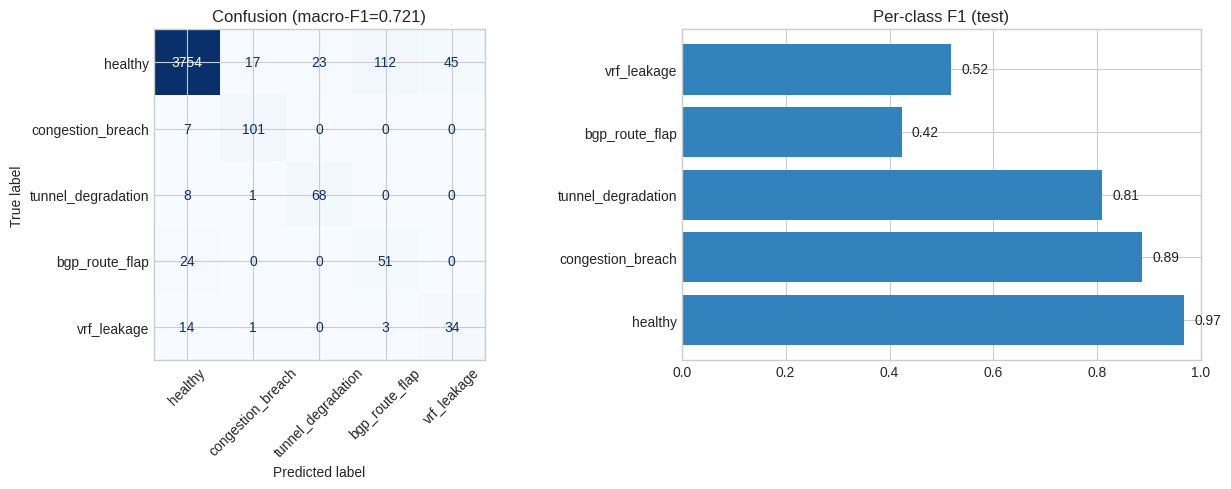

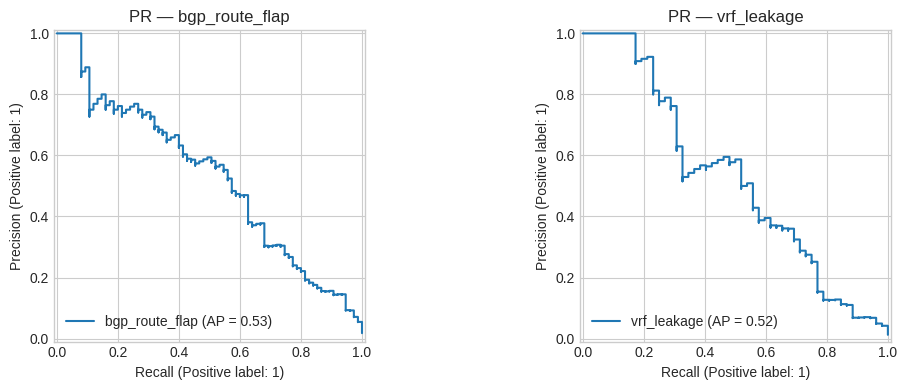

In [5]:
def inverse_frequency_weights(y: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=int)
    classes, counts = np.unique(y, return_counts=True)
    freq = {int(c): int(n) for c, n in zip(classes, counts)}
    k, n = len(classes), len(y)
    return np.array([n / (k * freq[int(yi)]) for yi in y], dtype=np.float64)

def predict_two_stage(gate, fault_clf, X, *, healthy_idx, local_to_global, gate_thr, class_thr):
    p_anom = gate.predict_proba(X)[:, 1]
    p_fault = fault_clf.predict_proba(X)
    local_classes = list(fault_clf.named_steps["xgb"].classes_)
    preds = np.full(len(p_anom), healthy_idx, dtype=int)
    for i in range(len(p_anom)):
        if p_anom[i] < gate_thr:
            continue
        scores = []
        for j, lid in enumerate(local_classes):
            gid = int(local_to_global[int(lid)])
            scores.append(p_fault[i, j] / max(class_thr.get(gid, 1.0), 1e-6))
        preds[i] = int(local_to_global[int(local_classes[int(np.argmax(scores))])])
    return preds

def predict_weighted_multiclass(gate, full_clf, X, *, healthy_idx, gate_thr, class_thr):
    p_anom = gate.predict_proba(X)[:, 1]
    p_full = full_clf.predict_proba(X)
    full_classes = list(full_clf.named_steps["xgb"].classes_)
    preds = np.full(len(p_anom), healthy_idx, dtype=int)
    for i in range(len(p_anom)):
        if p_anom[i] < gate_thr:
            continue
        scores = [p_full[i, j] / max(class_thr.get(int(cid), 1.0), 1e-6)
                  for j, cid in enumerate(full_classes)]
        preds[i] = int(full_classes[int(np.argmax(scores))])
    return preds

def tune_phase1(gate, fault_clf, full_clf, X_val, y_val, *, healthy_idx, fault_ids, local_to_global, rare_ids):
    gate_grid = [0.20, 0.30, 0.40, 0.50, 0.60]
    thr_grid = [0.50, 0.65, 0.80, 1.00, 1.20]
    best = {"mode": "two_stage", "gate_thr": 0.5, "class_thr": {int(c): 1.0 for c in fault_ids},
            "score": -1.0, "macro_f1": -1.0}

    def rare_aware(yt, yp):
        macro = f1_score(yt, yp, average="macro", zero_division=0)
        rares = [f1_score(yt == c, yp == c, zero_division=0) for c in rare_ids]
        return 0.4 * macro + 0.6 * float(np.mean(rares) if rares else macro), float(macro)

    for g in gate_grid:
        for rt in thr_grid:
            for ct in thr_grid:
                if rt > ct:
                    continue
                thrs = {int(c): (rt if c in rare_ids else ct) for c in fault_ids}
                pred = predict_two_stage(gate, fault_clf, X_val, healthy_idx=healthy_idx,
                                         local_to_global=local_to_global, gate_thr=g, class_thr=thrs)
                score, macro = rare_aware(y_val, pred)
                if score > best["score"]:
                    best.update(mode="two_stage", gate_thr=g, class_thr=thrs, score=score, macro_f1=macro)

    p_full = full_clf.predict_proba(X_val)
    full_classes = list(full_clf.named_steps["xgb"].classes_)
    p_anom = gate.predict_proba(X_val)[:, 1]
    for g in gate_grid:
        for rt in thr_grid:
            for ct in thr_grid:
                if rt > ct:
                    continue
                thrs = {int(c): (rt if int(c) in rare_ids else ct) for c in full_classes}
                thrs[int(healthy_idx)] = max(thrs.get(int(healthy_idx), 1.0), 1.0)
                preds = np.full(len(y_val), healthy_idx, dtype=int)
                for i in range(len(y_val)):
                    if p_anom[i] < g:
                        continue
                    scores = [p_full[i, j] / max(thrs[int(cid)], 1e-6) for j, cid in enumerate(full_classes)]
                    preds[i] = int(full_classes[int(np.argmax(scores))])
                score, macro = rare_aware(y_val, preds)
                if score > best["score"]:
                    best.update(mode="weighted_multiclass", gate_thr=g,
                                class_thr={int(k): float(v) for k, v in thrs.items()},
                                score=score, macro_f1=macro)
    return best

y_raw = df["unified_label"].astype(str)
keep = y_raw.value_counts()
mask = y_raw.isin(keep[keep >= 5].index)
X_all, y_raw = X.loc[mask], y_raw.loc[mask]
le_classes = [c for c in UNIFIED_LABELS if c in set(y_raw)]
le_classes += sorted(set(y_raw) - set(le_classes))
class_to_idx = {c: i for i, c in enumerate(le_classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
y = y_raw.map(class_to_idx).astype(int).values
healthy_idx = class_to_idx["healthy"]
fault_ids = [class_to_idx[c] for c in le_classes if c != "healthy"]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)

y_bin_fit = (y_fit != healthy_idx).astype(int)
gate = Pipeline([
    ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("xgb", XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.08,
                          subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE, n_jobs=-1)),
])
gate.fit(X_fit, y_bin_fit, xgb__sample_weight=inverse_frequency_weights(y_bin_fit))

fault_mask = y_fit != healthy_idx
X_fault, y_fault_g = X_fit.loc[fault_mask], y_fit[fault_mask]
g2l = {gid: i for i, gid in enumerate(fault_ids)}
l2g = {i: gid for gid, i in g2l.items()}
y_fault_l = np.array([g2l[int(g)] for g in y_fault_g], dtype=int)
fault_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("xgb", XGBClassifier(n_estimators=250, max_depth=5, learning_rate=0.08,
                          subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE, n_jobs=-1)),
])
fault_clf.fit(X_fault, y_fault_l, xgb__sample_weight=inverse_frequency_weights(y_fault_l))

full_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("xgb", XGBClassifier(n_estimators=250, max_depth=5, learning_rate=0.08,
                          subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE, n_jobs=-1)),
])
full_clf.fit(X_fit, y_fit, xgb__sample_weight=inverse_frequency_weights(y_fit))

supports = {int(c): int(np.sum(y_fit == c)) for c in fault_ids}
rare_ids = {c for c, _ in sorted(supports.items(), key=lambda t: t[1])[: max(1, len(supports)//2)]}
best = tune_phase1(gate, fault_clf, full_clf, X_val, y_val, healthy_idx=healthy_idx,
                   fault_ids=fault_ids, local_to_global=l2g, rare_ids=rare_ids)
mode, gate_thr, class_thr = best["mode"], best["gate_thr"], best["class_thr"]
print(f"mode={mode}  gate_thr={gate_thr:.2f}  val macro-F1={best['macro_f1']:.4f}  rare-aware={best['score']:.4f}")

if mode == "two_stage":
    pred = predict_two_stage(gate, fault_clf, X_test, healthy_idx=healthy_idx,
                             local_to_global=l2g, gate_thr=gate_thr, class_thr=class_thr)
else:
    pred = predict_weighted_multiclass(gate, full_clf, X_test, healthy_idx=healthy_idx,
                                       gate_thr=gate_thr, class_thr=class_thr)

macro_f1 = f1_score(y_test, pred, average="macro", zero_division=0)
weighted_f1 = f1_score(y_test, pred, average="weighted", zero_division=0)
accuracy = accuracy_score(y_test, pred)
report = classification_report(y_test, pred, labels=list(range(len(le_classes))),
                               target_names=le_classes, zero_division=0, output_dict=True)
print(f"test macro-F1={macro_f1:.4f}  weighted-F1={weighted_f1:.4f}")
print(classification_report(y_test, pred, labels=list(range(len(le_classes))),
                            target_names=le_classes, zero_division=0))

out_clf = model_dir("fault_classifier")
joblib.dump({
    "gate": gate, "fault_clf": fault_clf, "full_clf": full_clf, "mode": mode,
    "gate_thr": gate_thr, "class_thr": class_thr, "healthy_idx": healthy_idx,
    "fault_class_ids": fault_ids, "local_to_global": l2g, "global_to_local": g2l,
    "rare_global_ids": list(rare_ids), "phase": "phase1_tiers_1_2_3",
}, out_clf / "fault_classifier_xgb.pkl")
joblib.dump({
    "classes": le_classes, "mode": mode, "gate_thr": gate_thr,
    "class_thr": {(idx_to_class[k] if k in idx_to_class else str(k)): v for k, v in class_thr.items()},
    "smote": False, "smote_policy": "refused_tier4_temporal_integrity",
}, out_clf / "label_encoder.pkl")
(out_clf / "decision_thresholds.json").write_text(json.dumps({
    "mode": mode, "gate_thr": gate_thr,
    "class_thr": {(idx_to_class[k] if k in idx_to_class else str(k)): v for k, v in class_thr.items()},
    "val_macro_f1": best["macro_f1"], "rare_aware_score": best["score"],
}, indent=2))

cm = confusion_matrix(y_test, pred, labels=list(range(len(le_classes))))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(cm, display_labels=le_classes).plot(ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45)
axes[0].set_title(f"Confusion (macro-F1={macro_f1:.3f})")
f1s = [report[c]["f1-score"] for c in le_classes]
axes[1].barh(le_classes, f1s, color="#3182bd")
axes[1].set_xlim(0, 1)
axes[1].set_title("Per-class F1 (test)")
for i, v in enumerate(f1s):
    axes[1].text(v + 0.02, i, f"{v:.2f}", va="center")
fig.tight_layout()
fig.savefig(out_clf / "scorecard.png", dpi=140)
plt.show()

# PR curves for rare / fault classes
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cname in zip(axes, ["bgp_route_flap", "vrf_leakage"]):
    if cname not in class_to_idx:
        continue
    cid = class_to_idx[cname]
    # use full_clf fault probs when available
    if mode == "weighted_multiclass":
        proba = full_clf.predict_proba(X_test)
        classes = list(full_clf.named_steps["xgb"].classes_)
        j = list(classes).index(cid)
        scores = proba[:, j]
    else:
        proba = fault_clf.predict_proba(X_test)
        classes = list(fault_clf.named_steps["xgb"].classes_)
        # map local
        j = list(classes).index(g2l[cid]) if cid in g2l else 0
        scores = proba[:, j]
    PrecisionRecallDisplay.from_predictions((y_test == cid).astype(int), scores, ax=ax, name=cname)
    ax.set_title(f"PR — {cname}")
fig.tight_layout()
plt.show()

booster = (full_clf if mode == "weighted_multiclass" else fault_clf).named_steps["xgb"]
imp = booster.feature_importances_
top = sorted(zip(feats, imp), key=lambda t: t[1], reverse=True)[:12]
(out_clf / "feature_attribution.json").write_text(json.dumps(
    [{"feature": f, "importance": float(v)} for f, v in top], indent=2))

clf_stats = {
    "phase": "phase1_tiers_1_2_3",
    "mode": mode,
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "accuracy": float(accuracy),
    "gate_thr": float(gate_thr),
    "test_n": int(len(y_test)),
    "per_class_f1": {c: float(report[c]["f1-score"]) for c in le_classes},
    "per_class": {
        c: {
            "precision": float(report[c]["precision"]),
            "recall": float(report[c]["recall"]),
            "f1": float(report[c]["f1-score"]),
            "support": int(report[c]["support"]),
        }
        for c in le_classes
    },
    "classes": le_classes,
    "smote": False,
}


## Stage 3 — Prophet macro forecasts

One chart per metric: history + 24h forecast envelope.


12:07:19 - cmdstanpy - INFO - Chain [1] start processing
12:07:23 - cmdstanpy - INFO - Chain [1] done processing
12:07:24 - cmdstanpy - INFO - Chain [1] start processing
12:07:25 - cmdstanpy - INFO - Chain [1] done processing
12:07:26 - cmdstanpy - INFO - Chain [1] start processing
12:07:26 - cmdstanpy - INFO - Chain [1] done processing


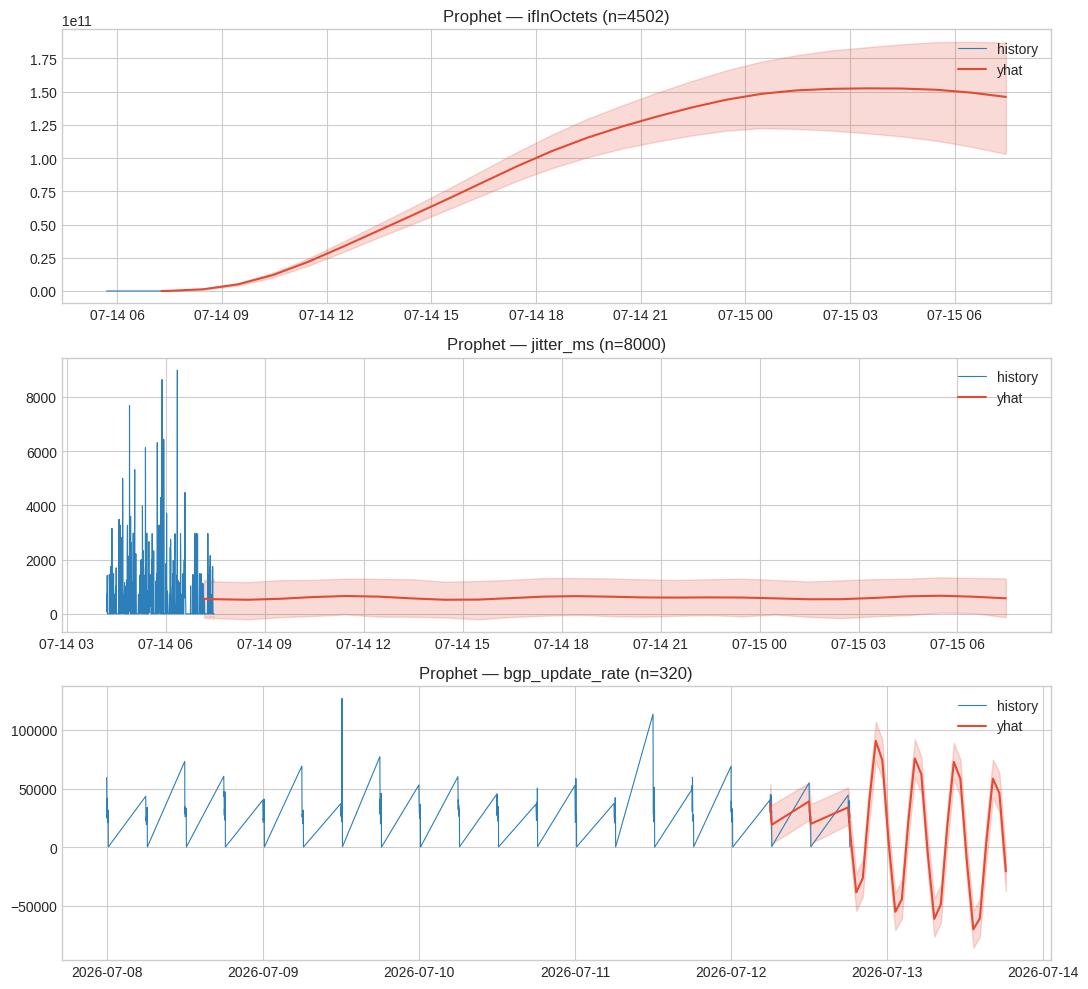

Prophet artifacts: ['prophet_ifInOctets', 'prophet_jitter_ms', 'prophet_bgp_update_rate']


In [6]:
raw = pd.read_parquet(PROCESSED_DIR / "deca_unified_raw.parquet")
raw["timestamp"] = pd.to_datetime(raw["timestamp"], utc=True)
prophet_arts = []
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=False)
for ax, (metric, folder) in zip(axes, [
    ("ifInOctets", "prophet_ifInOctets"),
    ("jitter_ms", "prophet_jitter_ms"),
    ("bgp_update_rate", "prophet_bgp_update_rate"),
]):
    series = (raw.loc[raw["metric"] == metric, ["timestamp", "value"]]
              .dropna().sort_values("timestamp").drop_duplicates("timestamp", keep="last"))
    if len(series) < 40:
        ax.set_title(f"{metric}: skipped (n={len(series)})")
        continue
    if len(series) > 8000:
        idx = np.linspace(0, len(series) - 1, 8000).astype(int)
        series = series.iloc[idx]
    pdf = pd.DataFrame({"ds": series["timestamp"].dt.tz_localize(None), "y": series["value"].astype(float)})
    m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False,
                changepoint_prior_scale=0.05)
    m.fit(pdf)
    future = m.make_future_dataframe(periods=24, freq="H")
    fc = m.predict(future)
    out = model_dir(folder)
    joblib.dump(m, out / f"{folder}.pkl")
    prophet_arts.append({"name": folder, "file": rel_model_path(folder, f"{folder}.pkl"),
                         "type": "prophet", "n": len(pdf)})
    # plot last 500 history + forecast tail
    hist = pdf.tail(500)
    ax.plot(hist["ds"], hist["y"], lw=0.8, color="#2c7fb8", label="history")
    tail = fc.tail(24 + 48)
    ax.plot(tail["ds"], tail["yhat"], color="#e34a33", label="yhat")
    ax.fill_between(tail["ds"], tail["yhat_lower"], tail["yhat_upper"], color="#e34a33", alpha=0.2)
    ax.set_title(f"Prophet — {metric} (n={len(pdf)})")
    ax.legend(loc="upper right")
fig.tight_layout()
plt.show()
print("Prophet artifacts:", [a["name"] for a in prophet_arts])


## Stage 4 — LSTM time-to-breach

Sliding windows ($T=16$) on network rows with finite `time_to_breach_minutes`.
Plots: training loss, predicted vs true scatter.


sequences=623
Epoch 1/12


E0000 00:00:1784097446.658802   86457 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 27.4707 - mae: 4.3563 - val_loss: 28.4481 - val_mae: 4.1711
Epoch 2/12
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 24.1605 - mae: 4.0126 - val_loss: 23.9393 - val_mae: 3.7003
Epoch 3/12
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 18.7535 - mae: 3.4318 - val_loss: 16.9074 - val_mae: 2.9881
Epoch 4/12
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 11.5972 - mae: 2.6493 - val_loss: 10.7562 - val_mae: 2.3823
Epoch 5/12
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 7.8042 - mae: 2.2361 - val_loss: 9.4477 - val_mae: 2.4631
Epoch 6/12
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 7.2938 - mae: 2.1964 - val_loss: 9.2488 - val_mae: 2.4674
Epoch 7/12
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 6.8037 - mae: 2.0888 - val_loss: 8.7909 - val_mae: 2.3378
Epoch 8/12
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 6.6078 - mae: 2.0283 - val_loss: 8.5799 - val_mae: 2.2875
Epoch 9/12
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 6.3958 - mae: 1.9959 - val

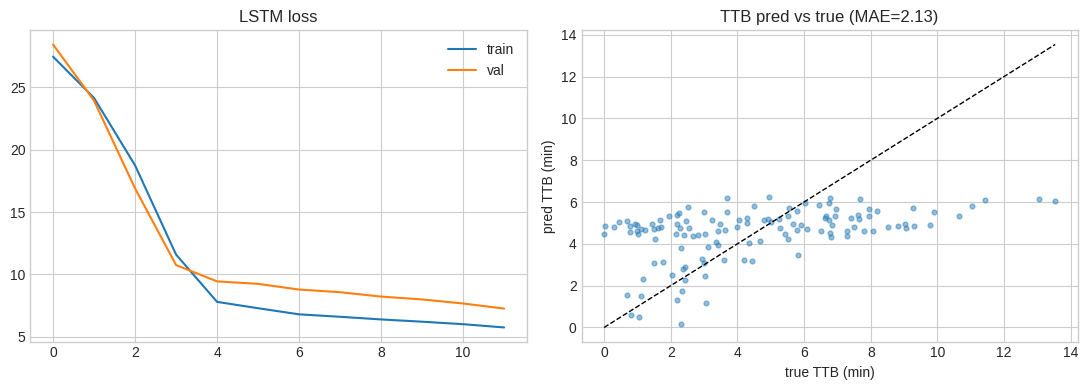

In [7]:
sub = df[df["source"] == "network"].copy().sort_index()
sub = sub[~sub.index.duplicated(keep="last")]
filled = sub[feats].copy()
filled = filled.fillna(filled.median(numeric_only=True)).fillna(0.0).astype(np.float32)
ttb = sub["time_to_breach_minutes"].astype(float).to_numpy()
mat = filled.to_numpy()
Xs, ys = [], []
for i in range(SEQ_LEN - 1, len(mat)):
    if np.isnan(ttb[i]):
        continue
    Xs.append(mat[i - SEQ_LEN + 1 : i + 1])
    ys.append(float(ttb[i]))
X_seq = np.asarray(Xs, dtype=np.float32)
y_seq = np.asarray(ys, dtype=np.float32)
print(f"sequences={len(X_seq)}")

lstm_stats = None
if len(X_seq) < 40:
    print("skip LSTM — need ≥40 sequences")
else:
    if len(X_seq) > 4000:
        rng = np.random.default_rng(RANDOM_STATE)
        pick = rng.choice(len(X_seq), size=4000, replace=False)
        X_seq, y_seq = X_seq[pick], y_seq[pick]
    Xtr, Xte, ytr, yte = train_test_split(X_seq, y_seq, test_size=0.2, random_state=RANDOM_STATE)
    flat = Xtr.reshape(-1, Xtr.shape[-1])
    mu, sigma = flat.mean(0), flat.std(0)
    sigma[sigma < 1e-8] = 1.0
    Xtr = (Xtr - mu) / sigma
    Xte = (Xte - mu) / sigma

    model = keras.Sequential([
        layers.Input(shape=(SEQ_LEN, len(feats))),
        layers.LSTM(64, return_sequences=True),
        layers.LSTM(32),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    hist = model.fit(Xtr, ytr, validation_split=0.15, epochs=12, batch_size=64, verbose=1)
    pred = model.predict(Xte, verbose=0).ravel()
    mae = mean_absolute_error(yte, pred)
    print(f"LSTM MAE={mae:.3f} min  test n={len(yte)}")

    out_l = model_dir("lstm")
    model.save(out_l / "fault_lstm_v1.keras")
    joblib.dump({"mean": mu, "std": sigma, "feature_columns": feats, "seq_len": SEQ_LEN},
                out_l / "lstm_scaler.pkl")
    lstm_stats = {"mae_minutes": float(mae), "n_sequences": int(len(X_seq))}

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(hist.history["loss"], label="train")
    axes[0].plot(hist.history["val_loss"], label="val")
    axes[0].set_title("LSTM loss")
    axes[0].legend()
    axes[1].scatter(yte, pred, s=12, alpha=0.5, c="#2c7fb8")
    lim = [min(yte.min(), pred.min()), max(yte.max(), pred.max())]
    axes[1].plot(lim, lim, "k--", lw=1)
    axes[1].set_xlabel("true TTB (min)")
    axes[1].set_ylabel("pred TTB (min)")
    axes[1].set_title(f"TTB pred vs true (MAE={mae:.2f})")
    fig.tight_layout()
    plt.show()


## Stage 5 — Feature attribution & CE–PE–CE topology


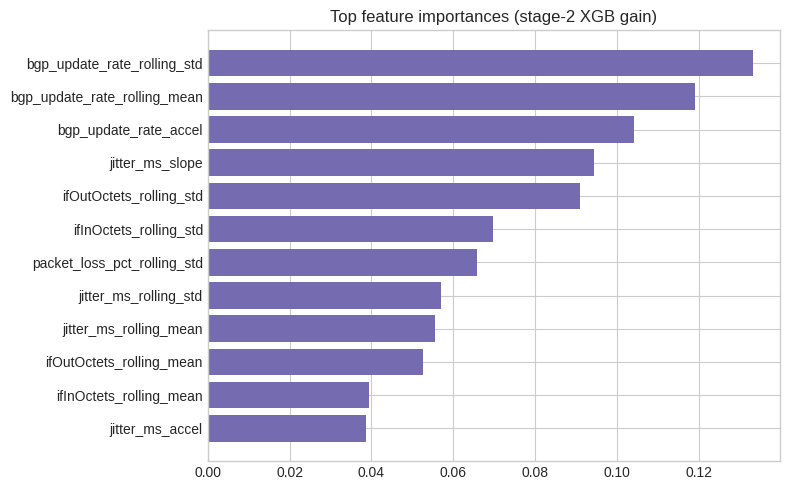

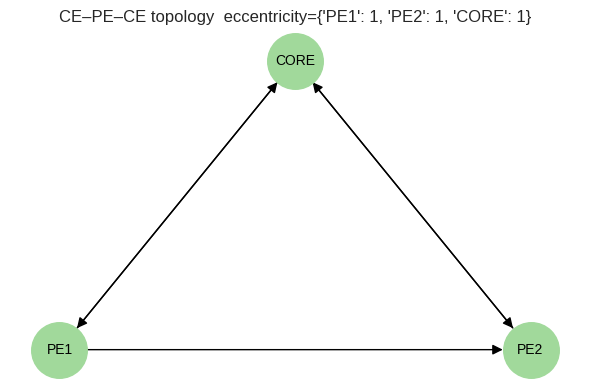

In [8]:
# Attribution bars (from classifier stage)
fig, ax = plt.subplots(figsize=(8, 5))
names = [t[0] for t in top][::-1]
vals = [t[1] for t in top][::-1]
ax.barh(names, vals, color="#756bb1")
ax.set_title("Top feature importances (stage-2 XGB gain)")
fig.tight_layout()
plt.show()

g = nx.DiGraph()
nodes = {
    "PE1": {"host": "station1", "ip": "192.168.50.10"},
    "PE2": {"host": "station2", "ip": "192.168.50.20"},
    "CORE": {"host": "station3", "ip": "192.168.50.30"},
}
for n, attrs in nodes.items():
    g.add_node(n, **attrs)
g.add_edge("PE1", "CORE", link="ce-pe")
g.add_edge("CORE", "PE1", link="pe-ce")
g.add_edge("PE2", "CORE", link="ce-pe")
g.add_edge("CORE", "PE2", link="pe-ce")
g.add_edge("PE1", "PE2", link="overlay")
und = g.to_undirected()
ecc = {n: nx.eccentricity(und, n) for n in und.nodes} if nx.is_connected(und) else {}
payload = {
    "nodes": [{"id": n, **nodes[n]} for n in g.nodes],
    "edges": [{"source": u, "target": v, **d} for u, v, d in g.edges(data=True)],
    "eccentricity": ecc,
}
out_t = model_dir("topology")
(out_t / "topology_graph.json").write_text(json.dumps(payload, indent=2))
joblib.dump(g, out_t / "topology_graph.pkl")

fig, ax = plt.subplots(figsize=(6, 4))
pos = {"PE1": (-1, 0), "CORE": (0, 0.6), "PE2": (1, 0)}
nx.draw_networkx(g, pos=pos, ax=ax, node_color="#a1d99b", node_size=1600,
                 font_size=10, arrows=True, arrowsize=15)
ax.set_title(f"CE–PE–CE topology  eccentricity={ecc}")
ax.axis("off")
fig.tight_layout()
plt.show()


## Stage 6 — Cumulative scoreboard + manifest

1. All-models scoreboard
2. Per-class table: **Class / Precision / Recall / F1 / Support**

The tables are in the **output** of the next cell (scroll below the code).


In [9]:
# ----- TABLE 1: cumulative model scoreboard -----
scoreboard_rows = [
    {
        "Component": "Isolation Forest + Platt",
        "Primary score": f"ROC-AUC {if_stats['auc']:.3f}",
        "Notes": "Unsupervised precursor / dashboard confidence",
    },
    {
        "Component": "XGBoost Phase 1 (tiers 1–3)",
        "Primary score": f"Macro-F1 {clf_stats['macro_f1']:.3f}, Acc {clf_stats['accuracy']:.2f}",
        "Notes": f"mode={clf_stats['mode']}; rare recall ↑; no SMOTE",
    },
]
if lstm_stats:
    scoreboard_rows.append({
        "Component": "LSTM time-to-breach",
        "Primary score": f"MAE {lstm_stats['mae_minutes']:.3f} min",
        "Notes": f"{lstm_stats.get('n_sequences', '?')} network sequences, T={SEQ_LEN}",
    })
else:
    scoreboard_rows.append({
        "Component": "LSTM time-to-breach",
        "Primary score": "skipped",
        "Notes": "not trained this run",
    })

if prophet_arts:
    pts = " / ".join(str(a.get("n", "?")) for a in prophet_arts)
    scoreboard_rows.append({
        "Component": "Prophet ×3",
        "Primary score": "Fit complete",
        "Notes": f"{pts} points (ifInOctets / jitter / bgp)",
    })
else:
    scoreboard_rows.append({
        "Component": "Prophet ×3",
        "Primary score": "skipped",
        "Notes": "not trained this run",
    })

top_note = ", ".join(t[0] for t in top[:3]) if top else "—"
scoreboard_rows.append({
    "Component": "Attribution",
    "Primary score": f"Top: {top_note}",
    "Notes": "Stage-2 XGB gain; no SMOTE",
})
scoreboard_rows.append({
    "Component": "Topology",
    "Primary score": f"e(v)={ecc}" if ecc else "written",
    "Notes": "PE1–PE2–CORE digraph",
})

scoreboard_df = pd.DataFrame(scoreboard_rows)

# ----- TABLE 2: Class / Precision / Recall / F1 / Support -----
per_class_rows = []
for cname, m in clf_stats["per_class"].items():
    per_class_rows.append({
        "Class": cname,
        "Precision": round(m["precision"], 2),
        "Recall": round(m["recall"], 2),
        "F1": round(m["f1"], 2),
        "Support": f"{m['support']:,}",
    })
per_class_df = pd.DataFrame(per_class_rows)

display(Markdown("### Cumulative model scoreboard"))
display(scoreboard_df)

display(Markdown(f"### Per-class scorecard (held-out test n={clf_stats['test_n']:,})"))
display(per_class_df)

scoreboard_df.to_csv(MODELS_DIR / "scoreboard_summary.csv", index=False)
per_class_df.to_csv(MODELS_DIR / "scoreboard_per_class.csv", index=False)

# ----- manifest -----
manifest = {
    "training_date": datetime.now(timezone.utc).isoformat(),
    "row_counts_by_source": df["source"].value_counts().to_dict(),
    "unified_label_counts": df["unified_label"].value_counts().to_dict(),
    "feature_columns": feats,
    "unified_labels": list(UNIFIED_LABELS),
    "roi_roadmap": {
        "phase1": "tiers_1_2_3_software",
        "phase2": "tier4_smote_refused",
        "phase3": "tiers_5_6_hardware_roadmap",
    },
    "scoreboard": {
        "summary": scoreboard_rows,
        "per_class": per_class_rows,
        "files": [
            "models/scoreboard_summary.csv",
            "models/scoreboard_per_class.csv",
        ],
    },
    "layout": {k: f"models/{v}/" for k, v in MODEL_DIRS.items()},
    "models": [
        {"name": "isolation_forest", "file": rel_model_path("isolation_forest", "isolation_forest.pkl"),
         "type": "sklearn", "metrics": if_stats},
        {"name": "confidence_calibrator", "file": rel_model_path("isolation_forest", "confidence_calibrator.pkl"),
         "type": "sklearn"},
        {"name": "fault_classifier_xgb", "file": rel_model_path("fault_classifier", "fault_classifier_xgb.pkl"),
         "type": "xgboost_two_stage", "metrics": clf_stats},
        {"name": "scorecard", "file": rel_model_path("fault_classifier", "scorecard.png"), "type": "artifact"},
        *prophet_arts,
    ],
}
if lstm_stats:
    manifest["models"].append({
        "name": "fault_lstm_v1", "file": rel_model_path("lstm", "fault_lstm_v1.keras"),
        "type": "keras", "metrics": lstm_stats,
    })
manifest["models"].append({
    "name": "topology_graph", "file": rel_model_path("topology", "topology_graph.json"),
    "type": "networkx", "metrics": {"eccentricity": ecc},
})
(MODELS_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
print("Wrote", MODELS_DIR / "manifest.json")
print("Wrote", MODELS_DIR / "scoreboard_summary.csv")
print("Wrote", MODELS_DIR / "scoreboard_per_class.csv")
print("Training complete.")


### Cumulative model scoreboard

,Component,Primary score,Notes
0,Isolation Forest + Platt,ROC-AUC 0.720,Unsupervised precursor / dashboard confidence
1,XGBoost Phase 1 (tiers 1–3),"Macro-F1 0.721, Acc 0.94",mode=weighted_multiclass; rare recall ↑; no SMOTE
2,LSTM time-to-breach,MAE 2.133 min,"623 network sequences, T=16"
3,Prophet ×3,Fit complete,4502 / 8000 / 320 points (ifInOctets / jitter ...
4,Attribution,"Top: bgp_update_rate_rolling_std, bgp_update_r...",Stage-2 XGB gain; no SMOTE
5,Topology,"e(v)={'PE1': 1, 'PE2': 1, 'CORE': 1}",PE1–PE2–CORE digraph


### Per-class scorecard (held-out test n=4,263)

,Class,Precision,Recall,F1,Support
0,healthy,0.99,0.95,0.97,"3,951"
1,congestion_breach,0.84,0.94,0.89,108
2,tunnel_degradation,0.75,0.88,0.81,77
3,bgp_route_flap,0.31,0.68,0.42,75
4,vrf_leakage,0.43,0.65,0.52,52


Wrote /home/brain/deca-isro/models/manifest.json
Wrote /home/brain/deca-isro/models/scoreboard_summary.csv
Wrote /home/brain/deca-isro/models/scoreboard_per_class.csv
Training complete.
